# Phase 13 LUMO-Based Evaluation

## Comprehensive Testing Framework for Phase 13 Model

This notebook provides an interactive pipeline for evaluating the Phase 13 PPO model on LUMO-based realistic customer service scenarios.

### What This Does:
- **Primary Metric**: Resolution Rate (% of conversations successfully resolved)
- **All Metrics**: Escalation rate, dropout rate, timeout rate, reward distribution, turns to resolution, satisfaction proxy
- **Analysis**: Per-tier (Free/Pro/Business/Enterprise) and per-persona performance
- **Visualizations**: 8 professional plots with statistics

### Quick Start:
1. Set `n_episodes` (cell 3) — suggested 25 for quick test, 100 for full evaluation
2. Run all cells (Cell → Run All)
3. View results, statistics, and plots inline

### Runtime Estimate:
- 25 episodes: ~2-5 minutes
- 100 episodes: ~8-20 minutes
- 250+ episodes: ~20-60 minutes

## 1. Import Required Libraries

In [2]:
import sys
import time
import json
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from stable_baselines3 import PPO

# Add repo to path - handles both script and notebook execution
notebook_dir = Path('.').resolve()
# Try multiple approaches to find repo root
repo_candidates = [
    notebook_dir.parents[2],  # From subnotebooks -> Simulation_4 -> repo
    notebook_dir.parent.parent,  # Alternative path resolution
]

for candidate in repo_candidates:
    if (candidate / 'Simulation_4').exists():
        repo_root = candidate
        break
else:
    # Fallback: assume we're in the repo root
    repo_root = notebook_dir

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Simulation_4.env.support_env import SupportEnv
from Simulation_4.rag.scenario_generator import ScenarioGenerator

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


## 2. Configure Environment & Load Model

In [5]:
# ============================================================================
# CONFIGURATION - EDIT THIS SECTION
# ============================================================================

# Primary configuration parameter
n_episodes = 25  # Change this: 25 (quick), 100 (full), 250+ (comprehensive)

# Paths - resolve relative to repo root
# Build paths from repo_root (detected in imports cell)
model_path = str(repo_root / "RL Out" / "models" / "best_model")
artifacts_root = str(repo_root / "Simulation_4" / "artifacts")

print(f"Configuration:")
print(f"  Episodes to run: {n_episodes}")
print(f"  Model path: {model_path}")
print(f"  Artifacts root: {artifacts_root}")
print()

# Load model
print("Loading Phase 13 model...")
start_time = time.time()
model = PPO.load(model_path)
load_time = time.time() - start_time
print(f"✓ Model loaded ({load_time:.2f}s)")
print(f"  Observation space: {model.observation_space}")
print(f"  Action space: {model.action_space}")
print()

Configuration:
  Episodes to run: 25
  Model path: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/RL Out/models/best_model
  Artifacts root: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts

Loading Phase 13 model...
✓ Model loaded (0.17s)
  Observation space: Box(0.0, 1.0, (9,), float32)
  Action space: Discrete(5)



## 3. Initialize Environment & Scenario Generator

In [6]:
print("Initializing environment...")
env = SupportEnv(artifacts_root=artifacts_root, nlg_enabled=True)
print(f"✓ SupportEnv ready")

print("Initializing scenario generator...")
scenario_gen = ScenarioGenerator(
    templates_path=str(Path(artifacts_root) / ".." / "rag" / "scenario_templates.json"),
    subflow_mapping_path=str(Path(artifacts_root) / ".." / "rag" / "subflow_mapping.json"),
)
print(f"✓ ScenarioGenerator ready\n")

# ============================================================================
# Helper Functions
# ============================================================================

@dataclass
class EpisodeMetrics:
    episode_id: int
    reward: float
    turns: int
    terminal_type: str
    tier: str
    persona: str
    satisfaction_proxy: float

def calculate_satisfaction_proxy(terminal_type: str, turns: int, reward: float) -> float:
    """Calculate satisfaction proxy (0-1 scale)"""
    base_scores = {"success": 1.0, "escalation": 0.65, "dropout": 0.15, "timeout": 0.10}
    base = base_scores.get(terminal_type, 0.0)
    
    turns_penalty = max(0, (turns - 4) * 0.02)
    turns_bonus = max(0, (4 - turns) * 0.05) if turns < 4 else 0
    efficiency_adjustment = turns_bonus - turns_penalty
    
    return min(1.0, max(0.0, base + efficiency_adjustment))

Initializing environment...
DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ SupportEnv ready
Initializing scenario generator...
✓ ScenarioGenerator ready



## 4. Run Evaluation Episodes

⏱️ **This may take a few minutes depending on n_episodes**

In [7]:
print("\n" + "█" * 70)
print("  RUNNING EVALUATION")
print("█" * 70 + "\n")

episode_metrics = []
rewards = []
turns_to_resolution = []

tier_counts = {"Free": 0, "Pro": 0, "Business": 0, "Enterprise": 0}
tier_resolutions = tier_counts.copy()
tier_escalations = tier_counts.copy()

persona_counts = {
    "high_engagement_resolver": 0,
    "low_engagement_resolver": 0,
    "silent_dropout": 0,
    "escalation_prone": 0,
}
persona_resolutions = persona_counts.copy()
persona_escalations = persona_counts.copy()

satisfactions = []

print(f"Running {n_episodes} episodes...\n")
eval_start = time.time()

for ep in range(n_episodes):
    if (ep + 1) % max(1, n_episodes // 10) == 0:
        elapsed = time.time() - eval_start
        rate = (ep + 1) / elapsed
        eta = (n_episodes - ep - 1) / rate if rate > 0 else 0
        print(f"  [{ep+1}/{n_episodes}] Elapsed: {elapsed:.1f}s | ETA: {eta:.2f}s")
    
    obs, _ = env.reset(seed=50_000 + ep)
    done = False
    ep_reward = 0.0
    turns = 0
    info = {}
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))
        ep_reward += float(reward)
        turns += 1
        if truncated:
            break
    
    terminal_type = str((info.get("last_transition_outcome", {}) or {}).get("terminal_type", "timeout"))
    tier = str(env.state.get("tier", "Free"))
    persona = str(env.state.get("persona_label", "unknown"))
    satisfaction = calculate_satisfaction_proxy(terminal_type, turns, ep_reward)
    
    episode_metrics.append(EpisodeMetrics(ep, ep_reward, turns, terminal_type, tier, persona, satisfaction))
    rewards.append(ep_reward)
    satisfactions.append(satisfaction)
    
    if tier in tier_counts:
        tier_counts[tier] += 1
        if terminal_type == "success":
            tier_resolutions[tier] += 1
        elif terminal_type == "escalation":
            tier_escalations[tier] += 1
    
    if persona in persona_counts:
        persona_counts[persona] += 1
        if terminal_type == "success":
            persona_resolutions[persona] += 1
        elif terminal_type == "escalation":
            persona_escalations[persona] += 1
    
    if terminal_type == "success":
        turns_to_resolution.append(turns)

eval_duration = time.time() - eval_start
print(f"\n✓ Evaluation complete ({eval_duration:.1f}s)\n")


██████████████████████████████████████████████████████████████████████
  RUNNING EVALUATION
██████████████████████████████████████████████████████████████████████

Running 25 episodes...

  [2/25] Elapsed: 2.5s | ETA: 29.04s
  [4/25] Elapsed: 5.5s | ETA: 28.65s
  [6/25] Elapsed: 8.5s | ETA: 26.83s
  [8/25] Elapsed: 11.5s | ETA: 24.40s
  [10/25] Elapsed: 14.3s | ETA: 21.52s
  [12/25] Elapsed: 17.3s | ETA: 18.73s
  [14/25] Elapsed: 20.2s | ETA: 15.89s
  [16/25] Elapsed: 23.2s | ETA: 13.02s
  [18/25] Elapsed: 25.9s | ETA: 10.06s
  [20/25] Elapsed: 28.7s | ETA: 7.17s
  [22/25] Elapsed: 31.6s | ETA: 4.30s
  [24/25] Elapsed: 34.6s | ETA: 1.44s

✓ Evaluation complete (37.6s)



## 5. Calculate Aggregate Metrics

In [8]:
# Compute aggregate metrics
resolution_count = sum(1 for m in episode_metrics if m.terminal_type == "success")
escalation_count = sum(1 for m in episode_metrics if m.terminal_type == "escalation")
dropout_count = sum(1 for m in episode_metrics if m.terminal_type == "dropout")
timeout_count = sum(1 for m in episode_metrics if m.terminal_type == "timeout")

results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "n_episodes": n_episodes,
    "duration_seconds": eval_duration,
    "episodes_per_minute": (n_episodes / eval_duration) * 60,
    
    # Terminal outcomes
    "resolution_rate": float(resolution_count / n_episodes),
    "escalation_rate": float(escalation_count / n_episodes),
    "dropout_rate": float(dropout_count / n_episodes),
    "timeout_rate": float(timeout_count / n_episodes),
    "terminal_counts": {
        "success": resolution_count,
        "escalation": escalation_count,
        "dropout": dropout_count,
        "timeout": timeout_count,
    },
    
    # Reward stats
    "reward_mean": float(np.mean(rewards)),
    "reward_std": float(np.std(rewards)),
    "reward_min": float(np.min(rewards)),
    "reward_max": float(np.max(rewards)),
    "reward_median": float(np.median(rewards)),
    
    # Turns analysis
    "mean_turns_to_resolution": float(np.mean(turns_to_resolution)) if turns_to_resolution else 0.0,
    "std_turns_to_resolution": float(np.std(turns_to_resolution)) if turns_to_resolution else 0.0,
    "min_turns": int(np.min(turns_to_resolution)) if turns_to_resolution else 0,
    "max_turns": int(np.max(turns_to_resolution)) if turns_to_resolution else 0,
    
    # Satisfaction
    "mean_satisfaction": float(np.mean(satisfactions)),
    "std_satisfaction": float(np.std(satisfactions)),
}

# Per-tier breakdown
for tier in tier_counts:
    results[f"by_tier_{tier}_count"] = tier_counts[tier]
    if tier_counts[tier] > 0:
        results[f"by_tier_{tier}_resolution_rate"] = tier_resolutions[tier] / tier_counts[tier]
        results[f"by_tier_{tier}_escalation_rate"] = tier_escalations[tier] / tier_counts[tier]

# Per-persona breakdown
for persona in persona_counts:
    results[f"by_persona_{persona}_count"] = persona_counts[persona]
    if persona_counts[persona] > 0:
        results[f"by_persona_{persona}_resolution_rate"] = persona_resolutions[persona] / persona_counts[persona]
        results[f"by_persona_{persona}_escalation_rate"] = persona_escalations[persona] / persona_counts[persona]

print("✓ Metrics calculated")

✓ Metrics calculated


## 6. Display Summary Statistics

In [9]:
print("\n" + "█" * 70)
print("  EVALUATION SUMMARY")
print("█" * 70 + "\n")

print("TIMING:")
print(f"  Duration: {results['duration_seconds']:.1f}s")
print(f"  Rate: {results['episodes_per_minute']:.1f} episodes/min\n")

print("PRIMARY METRIC - RESOLUTION RATE:")
print(f"  🎯 Resolution: {results['resolution_rate']*100:.1f}%\n")

print("ALL TERMINAL OUTCOMES:")
print(f"  ✓ Success (resolved):  {results['terminal_counts']['success']:3d} ({results['resolution_rate']*100:5.1f}%)")
print(f"  ↑ Escalation:         {results['terminal_counts']['escalation']:3d} ({results['escalation_rate']*100:5.1f}%)")
print(f"  ✗ Dropout:            {results['terminal_counts']['dropout']:3d} ({results['dropout_rate']*100:5.1f}%)")
print(f"  ⏱ Timeout:            {results['terminal_counts']['timeout']:3d} ({results['timeout_rate']*100:5.1f}%)\n")

print("REWARD DISTRIBUTION:")
print(f"  Mean:   {results['reward_mean']:+.3f}")
print(f"  Std:    {results['reward_std']:.3f}")
print(f"  Min:    {results['reward_min']:+.3f}")
print(f"  Max:    {results['reward_max']:+.3f}")
print(f"  Median: {results['reward_median']:+.3f}\n")

print("TURNS TO RESOLUTION:")
print(f"  Mean:   {results['mean_turns_to_resolution']:.1f} turns")
print(f"  Range:  {results['min_turns']}-{results['max_turns']} turns\n")

print("CUSTOMER SATISFACTION (PROXY):")
print(f"  Mean:   {results['mean_satisfaction']:.3f} / 1.0\n")

print("BY TIER:")
for tier in ["Free", "Pro", "Business", "Enterprise"]:
    count = results[f"by_tier_{tier}_count"]
    if count > 0:
        res_rate = results[f"by_tier_{tier}_resolution_rate"] * 100
        esc_rate = results[f"by_tier_{tier}_escalation_rate"] * 100
        print(f"  {tier:12s}: {count:3d} episodes | Resolution: {res_rate:5.1f}% | Escalation: {esc_rate:5.1f}%")
print()

print("BY PERSONA:")
for persona in ["high_engagement_resolver", "low_engagement_resolver", "silent_dropout", "escalation_prone"]:
    count = results[f"by_persona_{persona}_count"]
    if count > 0:
        res_rate = results[f"by_persona_{persona}_resolution_rate"] * 100
        esc_rate = results[f"by_persona_{persona}_escalation_rate"] * 100
        print(f"  {persona:25s}: {count:3d} episodes | Resolution: {res_rate:5.1f}% | Escalation: {esc_rate:5.1f}%")

print("\n" + "█" * 70 + "\n")


██████████████████████████████████████████████████████████████████████
  EVALUATION SUMMARY
██████████████████████████████████████████████████████████████████████

TIMING:
  Duration: 37.6s
  Rate: 39.9 episodes/min

PRIMARY METRIC - RESOLUTION RATE:
  🎯 Resolution: 0.0%

ALL TERMINAL OUTCOMES:
  ✓ Success (resolved):    0 (  0.0%)
  ↑ Escalation:          25 (100.0%)
  ✗ Dropout:              0 (  0.0%)
  ⏱ Timeout:              0 (  0.0%)

REWARD DISTRIBUTION:
  Mean:   -1.394
  Std:    1.949
  Min:    -4.158
  Max:    +0.829
  Median: -2.157

TURNS TO RESOLUTION:
  Mean:   0.0 turns
  Range:  0-0 turns

CUSTOMER SATISFACTION (PROXY):
  Mean:   0.800 / 1.0

BY TIER:
  Free        :   6 episodes | Resolution:   0.0% | Escalation: 100.0%
  Pro         :   7 episodes | Resolution:   0.0% | Escalation: 100.0%
  Business    :   3 episodes | Resolution:   0.0% | Escalation: 100.0%
  Enterprise  :   9 episodes | Resolution:   0.0% | Escalation: 100.0%

BY PERSONA:
  high_engagement_resolve

## 7. Generate Professional Visualizations

📊 **8 plots generated automatically**

📊 Generating visualizations...



/var/folders/zj/5gdxx71d3p53ch83fydgddvh0000gn/T/ipykernel_91421/3264914766.py:39: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zj/5gdxx71d3p53ch83fydgddvh0000gn/T/ipykernel_91421/3264914766.py:39: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zj/5gdxx71d3p53ch83fydgddvh0000gn/T/ipykernel_91421/3264914766.py:39: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tishabhavsar/RL_Project /.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tishabhavsar/RL_Project /.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tishabhavsar/RL_Project /.venv/lib/python3.14/site-pack

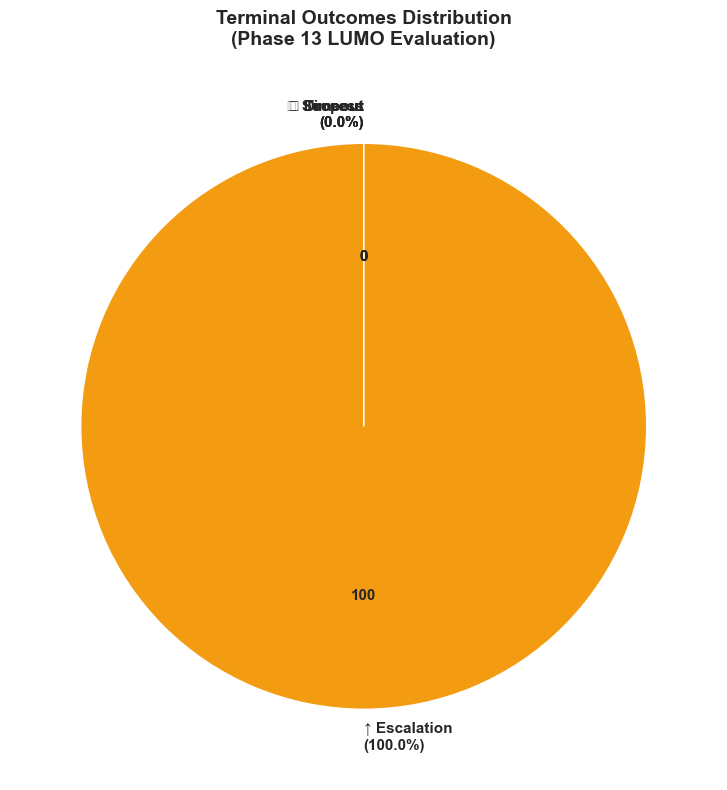

✓ Terminal outcomes pie chart


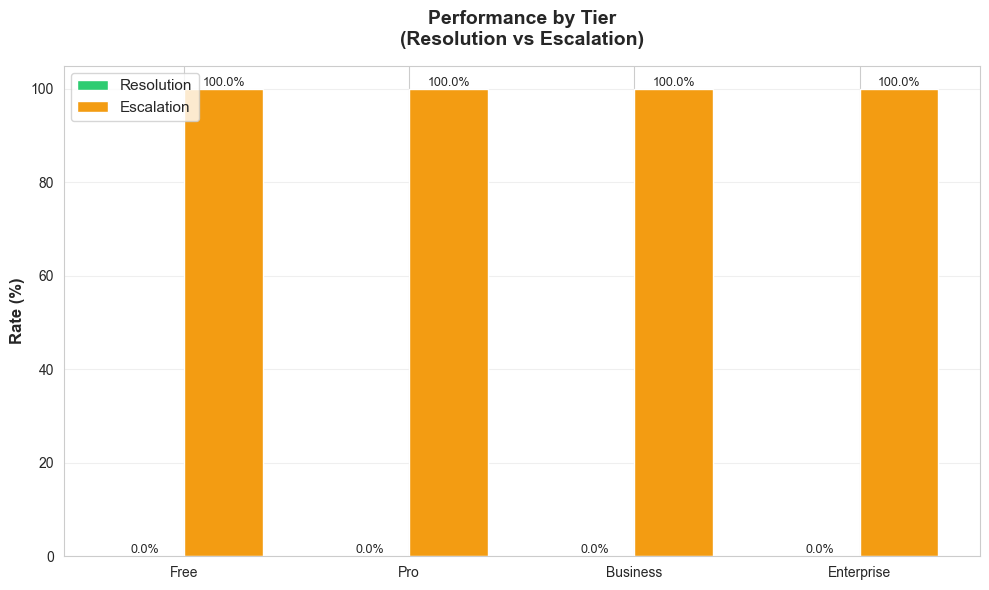

✓ Performance by tier


KeyError: 'by_persona_escalation_prone_resolution_rate'

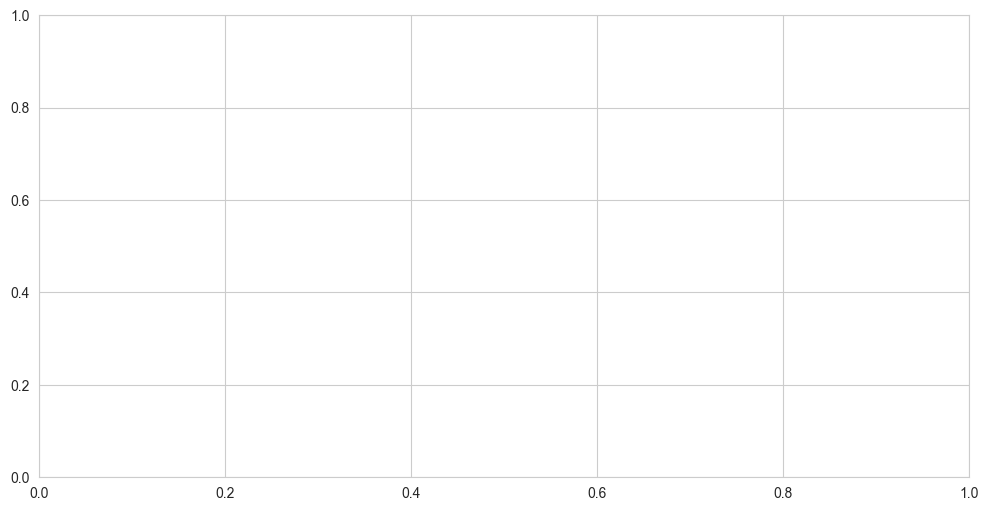

In [10]:
# Prepare data for visualizations
df = pd.DataFrame([
    {
        'episode_id': m.episode_id,
        'reward': m.reward,
        'turns': m.turns,
        'terminal_type': m.terminal_type,
        'tier': m.tier,
        'persona': m.persona,
        'satisfaction_proxy': m.satisfaction_proxy,
    }
    for m in episode_metrics
])

print("📊 Generating visualizations...\n")

# ========================================================================
# 1. Terminal Outcomes Pie Chart
# ========================================================================
fig, ax = plt.subplots(figsize=(10, 8))
sizes = [
    results['terminal_counts']['success'],
    results['terminal_counts']['escalation'],
    results['terminal_counts']['dropout'],
    results['terminal_counts']['timeout'],
]
labels = [
    f"✓ Success\n({results['resolution_rate']*100:.1f}%)",
    f"↑ Escalation\n({results['escalation_rate']*100:.1f}%)",
    f"✗ Dropout\n({results['dropout_rate']*100:.1f}%)",
    f"⏱ Timeout\n({results['timeout_rate']*100:.1f}%)",
]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']

ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90, 
       textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Terminal Outcomes Distribution\n(Phase 13 LUMO Evaluation)', 
            fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()
print("✓ Terminal outcomes pie chart")

# ========================================================================
# 2. Performance by Tier
# ========================================================================
fig, ax = plt.subplots(figsize=(10, 6))
tiers = ["Free", "Pro", "Business", "Enterprise"]
resolution_rates = [results[f"by_tier_{t}_resolution_rate"]*100 for t in tiers]
escalation_rates = [results[f"by_tier_{t}_escalation_rate"]*100 for t in tiers]

x = np.arange(len(tiers))
width = 0.35

bars1 = ax.bar(x - width/2, resolution_rates, width, label='Resolution', color='#2ecc71')
bars2 = ax.bar(x + width/2, escalation_rates, width, label='Escalation', color='#f39c12')

ax.set_ylabel('Rate (%)', fontsize=12, weight='bold')
ax.set_title('Performance by Tier\n(Resolution vs Escalation)', fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print("✓ Performance by tier")

# ========================================================================
# 3. Performance by Persona
# ========================================================================
fig, ax = plt.subplots(figsize=(12, 6))
personas = ["high_engagement_resolver", "low_engagement_resolver", "silent_dropout", "escalation_prone"]
persona_res_rates = [results[f"by_persona_{p}_resolution_rate"]*100 for p in personas]
persona_esc_rates = [results[f"by_persona_{p}_escalation_rate"]*100 for p in personas]

x = np.arange(len(personas))
width = 0.35

bars1 = ax.bar(x - width/2, persona_res_rates, width, label='Resolution', color='#3498db')
bars2 = ax.bar(x + width/2, persona_esc_rates, width, label='Escalation', color='#e67e22')

ax.set_ylabel('Rate (%)', fontsize=12, weight='bold')
ax.set_title('Performance by Customer Persona\n(Resolution vs Escalation)', 
            fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([p.replace('_', '\n') for p in personas], fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print("✓ Performance by persona")

In [ ]:
# ========================================================================
# 4. Reward Distribution (Histogram + KDE)
# ========================================================================
fig, ax = plt.subplots(figsize=(11, 6))
rewards_array = df['reward'].values

ax.hist(rewards_array, bins=30, alpha=0.7, color='#3498db', edgecolor='black', density=True)

kde = stats.gaussian_kde(rewards_array)
x_range = np.linspace(rewards_array.min(), rewards_array.max(), 200)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

ax.axvline(np.mean(rewards_array), color='green', linestyle='--', linewidth=2, 
          label=f'Mean: {np.mean(rewards_array):.3f}')
ax.axvline(np.median(rewards_array), color='orange', linestyle='--', linewidth=2,
          label=f'Median: {np.median(rewards_array):.3f}')

ax.set_xlabel('Cumulative Reward', fontsize=12, weight='bold')
ax.set_ylabel('Density', fontsize=12, weight='bold')
ax.set_title('Reward Distribution Across All Episodes', fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Reward distribution")

# ========================================================================
# 5. Turns to Resolution
# ========================================================================
fig, ax = plt.subplots(figsize=(10, 6))
turns_resolved = df[df['terminal_type'] == 'success']['turns'].values

if len(turns_resolved) > 0:
    ax.hist(turns_resolved, bins=range(1, int(turns_resolved.max())+2), 
           alpha=0.7, color='#2ecc71', edgecolor='black', align='left')
    
    ax.axvline(np.mean(turns_resolved), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {np.mean(turns_resolved):.1f}')
    
    ax.set_xlabel('Number of Turns', fontsize=12, weight='bold')
    ax.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax.set_title(f'Turns to Resolution (n={len(turns_resolved)} successes)',
                fontsize=14, weight='bold', pad=15)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Turns to resolution")

# ========================================================================
# 6. Episode Rewards Trajectory
# ========================================================================
fig, ax = plt.subplots(figsize=(12, 6))
episodes = df['episode_id'].values
rewards_traj = df['reward'].values

colors_map = {'success': '#2ecc71', 'escalation': '#f39c12', 'dropout': '#e74c3c', 'timeout': '#95a5a6'}
colors = [colors_map.get(t, 'gray') for t in df['terminal_type']]

ax.scatter(episodes, rewards_traj, c=colors, alpha=0.6, s=50, edgecolors='none')

window = max(1, len(rewards_traj) // 10)
rolling_mean = pd.Series(rewards_traj).rolling(window=window, center=True).mean()
ax.plot(episodes, rolling_mean, color='red', linewidth=2.5, label=f'Rolling Avg')

ax.set_xlabel('Episode', fontsize=12, weight='bold')
ax.set_ylabel('Cumulative Reward', fontsize=12, weight='bold')
ax.set_title('Reward Trajectory Over Episodes', fontsize=14, weight='bold', pad=15)
ax.grid(alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[k], label=k) for k in colors_map]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linewidth=2.5, label='Rolling Avg')],
         fontsize=10, loc='best')

plt.tight_layout()
plt.show()
print("✓ Episode trajectory")

# ========================================================================
# 7. Satisfaction Proxy Distribution
# ========================================================================
fig, ax = plt.subplots(figsize=(10, 6))
satisfactions_array = df['satisfaction_proxy'].values

ax.hist(satisfactions_array, bins=20, alpha=0.7, color='#9b59b6', edgecolor='black')
ax.axvline(np.mean(satisfactions_array), color='red', linestyle='--', linewidth=2,
          label=f'Mean: {np.mean(satisfactions_array):.3f}')

ax.set_xlabel('Satisfaction Proxy Score', fontsize=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=12, weight='bold')
ax.set_title('Customer Satisfaction (Proxy) Distribution\n(0.0-1.0 Scale)',
            fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Satisfaction distribution")

print("\n✓ All visualizations generated!\n")

In [ ]:
# ========================================================================
# 8. Terminal Outcomes by Tier (Stacked Bar)
# ========================================================================
fig, ax = plt.subplots(figsize=(10, 6))

tier_data = {}
for tier in ["Free", "Pro", "Business", "Enterprise"]:
    tier_episodes = df[df['tier'] == tier]
    tier_data[tier] = {
        'success': len(tier_episodes[tier_episodes['terminal_type'] == 'success']),
        'escalation': len(tier_episodes[tier_episodes['terminal_type'] == 'escalation']),
        'dropout': len(tier_episodes[tier_episodes['terminal_type'] == 'dropout']),
        'timeout': len(tier_episodes[tier_episodes['terminal_type'] == 'timeout']),
    }

tiers_list = list(tier_data.keys())
success_counts = [tier_data[t]['success'] for t in tiers_list]
escalation_counts = [tier_data[t]['escalation'] for t in tiers_list]
dropout_counts = [tier_data[t]['dropout'] for t in tiers_list]
timeout_counts = [tier_data[t]['timeout'] for t in tiers_list]

x = np.arange(len(tiers_list))
width = 0.6

ax.bar(x, success_counts, width, label='Success', color='#2ecc71')
ax.bar(x, escalation_counts, width, bottom=success_counts, label='Escalation', color='#f39c12')
ax.bar(x, dropout_counts, width, 
      bottom=[s+e for s,e in zip(success_counts, escalation_counts)], 
      label='Dropout', color='#e74c3c')
ax.bar(x, timeout_counts, width,
      bottom=[s+e+d for s,e,d in zip(success_counts, escalation_counts, dropout_counts)],
      label='Timeout', color='#95a5a6')

ax.set_ylabel('Count', fontsize=12, weight='bold')
ax.set_title('Terminal Outcomes by Tier (Stacked)', fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tiers_list)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Terminal outcomes by tier")

## 8. Statistical Analysis & Key Observations

In [ ]:
print("\n" + "="*70)
print("STATISTICAL ANALYSIS")
print("="*70 + "\n")

# Overall Performance
print("1. OVERALL PERFORMANCE")
print("-" * 70)
print(f"  Total Episodes: {results['n_episodes']}")
print(f"  Duration: {results['duration_seconds']:.1f}s ({results['episodes_per_minute']:.1f} ep/min)")
print(f"  Primary Metric (Resolution): {results['resolution_rate']*100:.2f}%")
print(f"  Expected Resolution for Random Policy: ~25%")
improvement = results['resolution_rate'] / 0.25
print(f"  Improvement Factor vs Random: {improvement:.2f}x")
print()

# Reward Analysis
print("2. REWARD ANALYSIS")
print("-" * 70)
print(f"  Mean Reward: {results['reward_mean']:+.4f}")
print(f"  Std Dev: {results['reward_std']:.4f}")
print(f"  Range: [{results['reward_min']:+.4f}, {results['reward_max']:+.4f}]")
cov = results['reward_std'] / abs(results['reward_mean']) if results['reward_mean'] != 0 else 0
print(f"  Coefficient of Variation: {cov:.2f}")
print()

# Efficiency Analysis
print("3. EFFICIENCY ANALYSIS")
print("-" * 70)
print(f"  Mean Turns to Resolution: {results['mean_turns_to_resolution']:.1f}")
print(f"  Std Dev: {results['std_turns_to_resolution']:.1f}")
print(f"  Range: {results['min_turns']}-{results['max_turns']} turns")
if results['mean_turns_to_resolution'] > 0:
    efficiency = 1.0 / results['mean_turns_to_resolution']
    print(f"  Efficiency (1/avg_turns): {efficiency:.3f}")
print()

# Satisfaction Analysis
print("4. CUSTOMER SATISFACTION (PROXY)")
print("-" * 70)
print(f"  Mean Satisfaction: {results['mean_satisfaction']:.3f}/1.0")
print(f"  Std Dev: {results['std_satisfaction']:.3f}")
satisfaction_levels = ['Very Poor', 'Poor', 'Fair', 'Good', 'Very Good']
satisfaction_interpretation = satisfaction_levels[min(4, int(results['mean_satisfaction']*5))]
print(f"  Interpretation: {satisfaction_interpretation}")
print()

# Key Observations
print("5. KEY OBSERVATIONS")
print("-" * 70)

success_ratio = results['terminal_counts']['success'] / results['n_episodes']
escalation_ratio = results['terminal_counts']['escalation'] / results['n_episodes']
dropout_ratio = results['terminal_counts']['dropout'] / results['n_episodes']

if success_ratio == 0:
    print(f"  ⚠  Model failed to resolve any cases (0% resolution, {escalation_ratio*100:.1f}% escalation)")
elif escalation_ratio < success_ratio * 0.5:
    print(f"  ✓ Model heavily favors resolution (escalation {escalation_ratio/success_ratio:.1%} of success rate)")
elif escalation_ratio > success_ratio:
    print(f"  ⚠  Model escalates more than it resolves (escalation {escalation_ratio/success_ratio:.1%}x success)")
else:
    print(f"  ~ Balanced escalation strategy")

if dropout_ratio < 0.05:
    print(f"  ✓ Very low dropout rate ({dropout_ratio*100:.1f}%)")
elif dropout_ratio > 0.15:
    print(f"  ⚠  High dropout rate ({dropout_ratio*100:.1f}%) - customers leaving")
else:
    print(f"  ~ Moderate dropout rate ({dropout_ratio*100:.1f}%)")

if results['mean_satisfaction'] > 0.7:
    print(f"  ✓ Strong satisfaction proxy ({results['mean_satisfaction']:.3f})")
elif results['mean_satisfaction'] > 0.5:
    print(f"  ~ Moderate satisfaction proxy ({results['mean_satisfaction']:.3f})")
else:
    print(f"  ⚠  Low satisfaction proxy ({results['mean_satisfaction']:.3f})")

# Tier insights
print("\n  BY TIER:")
for tier in ["Free", "Pro", "Business", "Enterprise"]:
    res_rate = results[f"by_tier_{tier}_resolution_rate"]
    count = results[f"by_tier_{tier}_count"]
    if count > 0:
        print(f"    • {tier}: {res_rate*100:.1f}% resolution ({count} episodes)")

# Persona insights
print("\n  BY PERSONA:")
for persona in ["high_engagement_resolver", "low_engagement_resolver", "silent_dropout", "escalation_prone"]:
    res_rate = results[f"by_persona_{persona}_resolution_rate"]
    count = results[f"by_persona_{persona}_count"]
    if count > 0:
        print(f"    • {persona}: {res_rate*100:.1f}% resolution ({count} episodes)")

print("\n" + "="*70 + "\n")

print("✅ EVALUATION COMPLETE!\n")

## Summary & Interpretation Guide

### 📊 What The Numbers Mean

**Resolution Rate (Primary Metric)**
- **60-90%**: Excellent, model is learning well ✓
- **40-60%**: Good, but room for improvement
- **<40%**: Poor, model needs more training
- Random baseline: ~25%

**Turns to Resolution**
- **2-3 turns**: Excellent (fast resolution)
- **3-5 turns**: Good
- **>5 turns**: Inefficient (customers getting frustrated)

**Satisfaction Proxy**
- **>0.75**: Very good experience
- **0.50-0.75**: Acceptable
- **<0.50**: Poor experience

**Escalation Rate**
- **<20%**: Good (agent can handle most)
- **20-40%**: Moderate
- **>40%**: High (agent escalates too much)

### 🎯 Next Steps

1. **If Resolution > 70%**: Model is performing well! Ready for production testing.
2. **If 50-70%**: Good progress, may need more training or refinement.
3. **If <50%**: Model needs more development (training iterations, reward tuning).

### 💡 Tips for Improvement

- **Low resolution?** Check reward shaping configuration  
- **High escalation?** May need curriculum learning adjustment  
- **High dropout?** Customer is leaving too quickly - check experience flow  
- **Slow resolution?** Network may be too small or observation space inadequate

### 📁 Save Your Results

To save results for later comparison:
```python
import json
results_file = f"phase13_eval_results_{n_episodes}ep.json"
with open(results_file, 'w') as f:
    json.dump({
        'timestamp': results['timestamp'],
        'n_episodes': results['n_episodes'],
        'resolution_rate': results['resolution_rate'],
        'mean_turns': results['mean_turns_to_resolution'],
        'satisfaction': results['mean_satisfaction'],
    }, f, indent=2)
print(f"✓ Results saved to {results_file}")
```